In [ ]:
# Install the Qiskit library into the current Python/Colab environment
# "!" runs a system (terminal) command inside Jupyter/Colab
# pip is Python’s package manager
# install tells pip to download and install the package named "qiskit"
%pip install qiskit

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Install Qiskit Aer (the high-performance simulator backend for Qiskit)
# Allows us to simulate quantum circuits locally without real quantum hardware
# Required for running circuits and getting measurement results

%pip install qiskit_aer

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Install Matplotlib for plotting and visualising results
# Used to draw circuit diagrams and display histograms of measurement outcomes
# Helps us interpret quantum results graphically

%pip install matplotlib


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
# Install Qiskit IBM Runtime package
# Provides access to IBM Quantum cloud services and real quantum hardware
# "-q" means quiet mode (reduces installation output in the notebook)
# Needed to use advanced primitives like Sampler and Estimator on IBM backends

%pip install -q qiskit-ibm-runtime


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [11]:
# Install Qiskit with visualization extras and additional plotting dependencies
# "qiskit[visualization]" installs optional packages required for drawing circuits nicely
# matplotlib is used for plotting histograms and visual outputs
# pylatexenc enables proper LaTeX-style rendering in circuit diagrams
# "-q" runs the installation in quiet mode (less console output)

%pip install -q "qiskit[visualization]" matplotlib pylatexenc


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
# Import the QuantumCircuit class from Qiskit
# Used to create and build quantum circuits (add qubits, gates, measurements)
from qiskit import QuantumCircuit

# Import SparsePauliOp from the quantum_info module
# Used to define quantum observables (such as Z, ZZ operators)
# Commonly used when computing expectation values
from qiskit.quantum_info import SparsePauliOp

# Import AerSimulator backend from Qiskit Aer
# Allows us to simulate quantum circuits locally (no real hardware needed)
from qiskit_aer import AerSimulator

# Import generate_preset_pass_manager from the transpiler module
# Used to optimise (transpile) circuits for specific hardware backends
from qiskit.transpiler import generate_preset_pass_manager

# Import EstimatorV2 from IBM Runtime and rename it as Estimator
# Used to compute expectation values of observables like ⟨Z⟩ and ⟨ZZ⟩
from qiskit_ibm_runtime import EstimatorV2 as Estimator


ModuleNotFoundError: No module named 'qiskit'

**Pauli-X Gate**

In [ ]:
# Create an AerSimulator instance
# method='statevector' tells the simulator to compute the full quantum statevector
# This allows us to access amplitude information instead of just measurement counts
# Useful when we want to analyse the exact quantum state before measurement

sim = AerSimulator(method='statevector')


In [ ]:
# Import plot_bloch_multivector from Qiskit's visualization module
# Used to visualise a quantum state on the Bloch sphere
# Helps us understand superposition and phase geometrically
# Commonly used when working with statevector simulations

from qiskit.visualization import plot_bloch_multivector


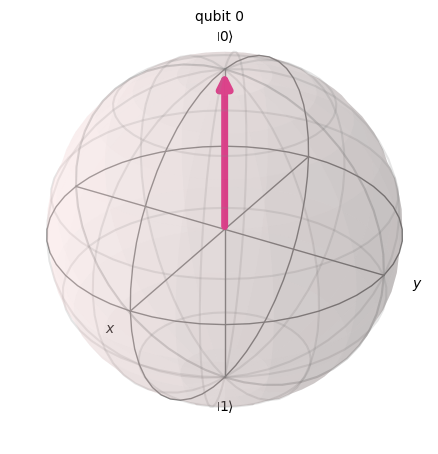

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩ by default)
qc = QuantumCircuit(1)

# Save the statevector so the simulator stores the full quantum state
# Required when using the statevector simulator to retrieve amplitudes
qc.save_statevector()

# Run the circuit on the simulator
# sim.run(qc) executes the circuit
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum state as a statevector object
state = sim.run(qc).result().get_statevector()

# Plot the state on the Bloch sphere
# Visualises the qubit’s position in 3D (shows superposition and phase)
plot_bloch_multivector(state)

# after ploting we will see a bloch sphere where the qubit is currently in the |0⟩ state

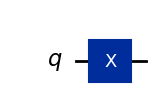

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩ by default)
qc = QuantumCircuit(1)

# Apply the Pauli-X gate to qubit 0
# X gate flips the qubit state: |0⟩ → |1⟩ and |1⟩ → |0⟩
qc.x(0)

# Draw the circuit using Matplotlib ("mpl" style)
# Displays a visual representation of the quantum circuit
qc.draw("mpl")


**Lets See the Results Again**

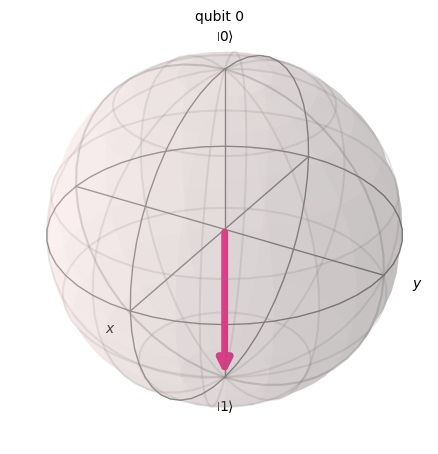

In [ ]:
# Save the statevector so the simulator stores the full quantum state
# Required when using the statevector simulator to retrieve amplitudes
qc.save_statevector()

# Execute the circuit on the simulator
# sim.run(qc) runs the circuit
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum state as a statevector
state = sim.run(qc).result().get_statevector()

# Plot the state on the Bloch sphere
# Visualises the qubit’s position in 3D space
plot_bloch_multivector(state)

# Bloch sphere: X gate flipped the qubit from |0⟩ to |1⟩

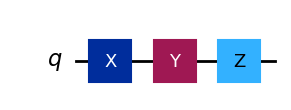

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply the Pauli-X gate
# Flips the state: |0⟩ ↔ |1⟩
qc.x(0)

# Apply the Pauli-Y gate
# Rotates the qubit around the Y-axis (introduces complex phase i)
qc.y(0)

# Apply the Pauli-Z gate
# Rotates around the Z-axis (adds phase to |1⟩ component)
qc.z(0)

# Draw the circuit using Matplotlib style
qc.draw("mpl")



In [ ]:
# Create a simulator instance (default measurement-based simulator)
sim = AerSimulator()

# Create a quantum circuit with 1 qubit and 1 classical bit
# The classical bit will store the measurement result
qc = QuantumCircuit(1, 1)

# Apply the X gate to flip |0⟩ → |1⟩
qc.x(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# Run the circuit 1024 times (shots)
# .result() retrieves the execution result
# .get_counts() returns the measurement outcome frequencies
sim.run(qc, shots=1024).result().get_counts()

# Since we applied the X gate, the qubit is in the |1⟩ state, so measuring it 1024 times should give {'1': 1024} (or very close).
#This confirms that the X gate deterministically flips the qubit from |0⟩ to |1⟩.


{'1': 1024}

**Z-Gate**

In [ ]:
# Create a quantum circuit with 1 qubit and 1 classical bit
# The classical bit will store the measurement result
qc = QuantumCircuit(1, 1)

# Apply the Z gate
# Z gate adds a phase to the |1⟩ component
# Since the initial state is |0⟩, this does not change measurement probability
qc.z(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# Run the circuit 1024 times and return measurement counts
sim.run(qc, shots=1024).result().get_counts()

# Even after applying the Z gate, the result will still be {'0': 1024} because Z only changes phase, not probability.
# Since the qubit started in |0⟩, and Z does not affect |0⟩, the measurement outcome remains 0 every time.


{'0': 1024}

**Y gate**

In [ ]:
# Create a quantum circuit with 1 qubit and 1 classical bit
# The classical bit will store the measurement result
qc = QuantumCircuit(1, 1)

# Apply the Y gate
# Y gate rotates the qubit around the Y-axis
# It flips |0⟩ to i|1⟩ (adds a complex phase factor i)
qc.y(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# Run the circuit 1024 times and return measurement counts
sim.run(qc, shots=1024).result().get_counts()

#The Y gate flips |0⟩ to i|1⟩, and since global phase does not affect measurement, the result will be {'1': 1024}.
#Even though a complex phase is introduced, the measurement probability is still 100% for state |1⟩.

{'1': 1024}

**H Gate**

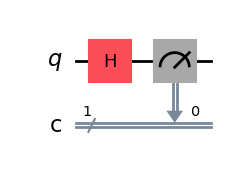

In [ ]:
# Create a quantum circuit with 1 qubit and 1 classical bit
# The classical bit will store the measurement result
qc = QuantumCircuit(1, 1)

# Apply the Hadamard (H) gate
# H gate creates superposition: |0⟩ → (|0⟩ + |1⟩) / √2
# This means equal probability of measuring 0 or 1
qc.h(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

# Draw the circuit using Matplotlib style
qc.draw("mpl")

#The Hadamard gate puts the qubit into an equal superposition of |0⟩ and |1⟩, so when we measure it, we expect roughly 50% 0 and 50% 1.

**Lets's See the Results**

In [ ]:
# Import plot_bloch_multivector to visualise a quantum state on the Bloch sphere
# Used when working with statevector simulations to see superposition and phase

# Import plot_histogram to display measurement results
# Used to visualise counts (probability distribution) from multiple shots

from qiskit.visualization import plot_bloch_multivector, plot_histogram


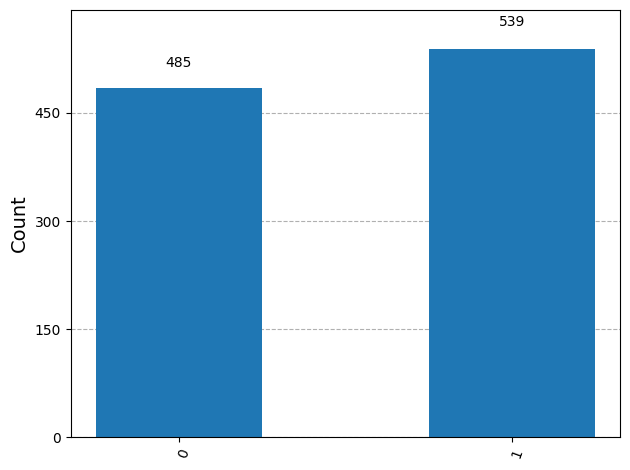

In [ ]:
# Create a simulator instance to run the quantum circuit locally
sim = AerSimulator()

# Execute the circuit 1024 times (shots)
# .run(qc) runs the circuit
# shots=1024 repeats the experiment 1024 times
# .result() retrieves the execution result
# .get_counts() returns the measurement outcome frequencies
res = sim.run(qc, shots=1024).result().get_counts()

# Plot the measurement results as a histogram
# Shows the probability distribution of outcomes (0 and 1)
plot_histogram(res)

#The small difference between the bars is just statistical fluctuation, if we increase the number of shots, the results will get even closer to 50% each

**No Hadamard**

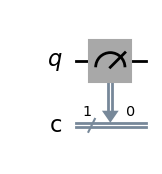

In [ ]:
# Create a quantum circuit with 1 qubit and 1 classical bit
# The qubit starts in the default state |0⟩
qc = QuantumCircuit(1, 1)

# Measure qubit 0 and store the result in classical bit 0
# Since no gates were applied, the qubit remains in |0⟩
qc.measure(0, 0)

# Draw the circuit using Matplotlib style
qc.draw("mpl")

#Since we did not apply any gates, the qubit stayed in its initial state |0⟩. Therefore, measuring it will always give 0 with 100% probability.


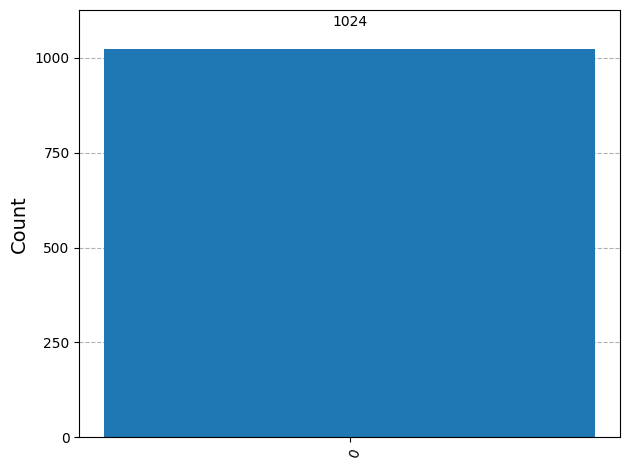

In [ ]:
# Create a simulator instance to run the quantum circuit locally
sim = AerSimulator()

# Execute the circuit 1024 times (shots)
# shots=1024 repeats the measurement 1024 times
# .result() retrieves the execution result
# .get_counts() returns the frequency of measurement outcomes
res = sim.run(qc, shots=1024).result().get_counts()

# Plot the measurement results as a histogram
# Displays how many times each outcome (0 or 1) was observed
plot_histogram(res)
#Since no gate was applied, the qubit remained in |0⟩, so the histogram should show 1024 counts of 0 and 0 counts of 1.
#This confirms that measurement is deterministic when the qubit is not in superposition.


**P-Gate**

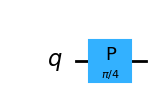

In [ ]:
# Import NumPy library for numerical operations
# Used here to access the constant π (pi)
import numpy as np

# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply the Phase (P) gate with angle π/4 to qubit 0
# p(theta) performs a rotation around the Z-axis by angle theta
# Here theta = π/4 (45 degrees)
qc.p(np.pi/4, 0)

# Draw the circuit using Matplotlib style
qc.draw("mpl")

#The P gate rotates the qubit around the Z-axis by 45 degrees, which changes the phase of the |1⟩ component.
#Since the qubit is still in |0⟩, this phase change does not affect measurement probabilities yet.


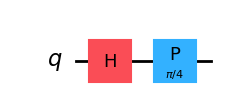

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply the Hadamard gate
# Transforms |0⟩ → (|0⟩ + |1⟩)/√2, placing the state on the equator (|+⟩ state)
qc.h(0)

# Apply the Phase (P) gate with angle π/4
# Performs a rotation around the Z-axis by 45 degrees
# Changes the relative phase between |0⟩ and |1⟩
qc.p(np.pi/4, 0)

# Draw the circuit using Matplotlib style
qc.draw("mpl")

#The Hadamard gate first moves the qubit to the equator of the Bloch sphere (equal superposition).
#The phase gate then rotates the state around the Z-axis, changing the phase but not the measurement probability.


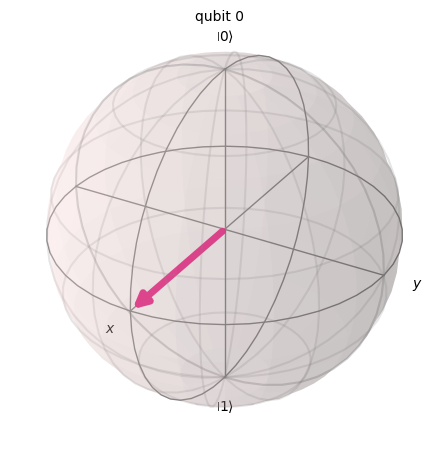

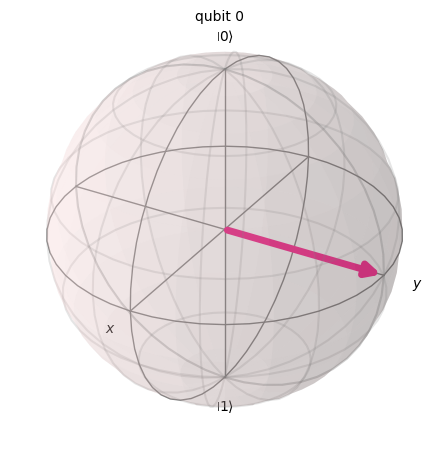

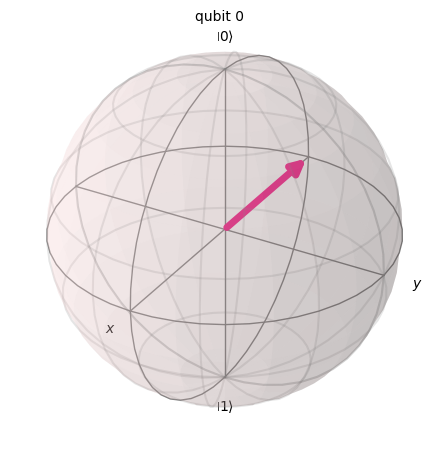

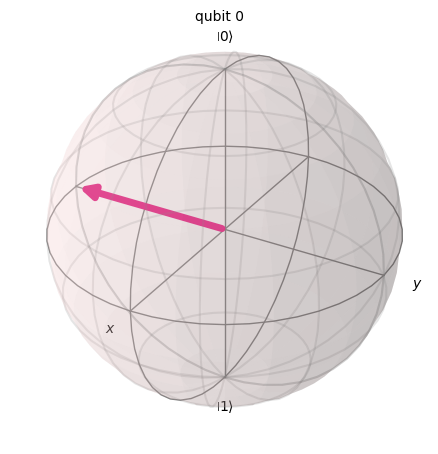

In [ ]:
# Create a simulator instance (statevector simulation by default here)
sim = AerSimulator()

# Define different rotation angles for the phase gate
angles  = [0, np.pi/2, np.pi, 3*np.pi/2]

# Labels for displaying which angle is being applied
labels  = ["0", "π/2", "π", "3π/2"]

# Loop through each angle and corresponding label
for theta, label in zip(angles, labels):

    # Create a new quantum circuit with 1 qubit
    qc = QuantumCircuit(1)

    # Apply Hadamard to move |0⟩ → |+⟩ (equator of Bloch sphere)
    qc.h(0)

    # Apply Phase (P) gate with angle theta
    # Rotates the qubit around the Z-axis by theta
    qc.p(theta, 0)

    # Save the statevector so we can retrieve the exact quantum state
    qc.save_statevector()

    # Execute the circuit on the simulator
    result = sim.run(qc).result()

    # Extract the final quantum statevector
    state = result.get_statevector()

    # Plot the Bloch sphere representation of the state
    plot_bloch_multivector(state)

    # Display the Bloch sphere explicitly (useful in notebooks)
    display(plot_bloch_multivector(state))




**Rotation Gates**

**Rx Gate**

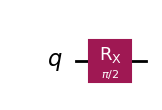

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply an Rx rotation by π/2 (90 degrees) to qubit 0
# Rx(theta) rotates the qubit around the X-axis by angle theta
# Here theta = π/2, so the state moves 90° on the Bloch sphere
qc.rx(np.pi/2, 0)

# Draw the circuit using Matplotlib style
qc.draw('mpl')

#The Rx(π/2) gate rotates the qubit 90 degrees around the X-axis of the Bloch sphere.
#Starting from |0⟩, the state moves toward the equator, creating a superposition with a specific phase.


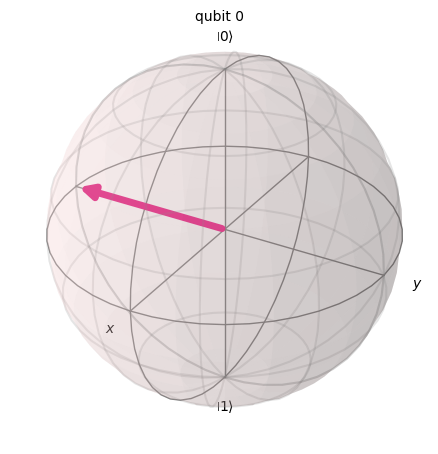

In [ ]:
# Save the statevector so the simulator stores the full quantum state
# Required to retrieve the exact amplitudes of the qubit
qc.save_statevector()

# Execute the circuit on the simulator
# .run(qc) runs the circuit
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum state
state = sim.run(qc).result().get_statevector()

# Plot the state on the Bloch sphere
# Shows the geometric position of the qubit after the Rx rotation
plot_bloch_multivector(state)

#After applying Rx(π/2), the qubit moves 90° from the north pole toward the equator along the X-axis.
#The Bloch sphere now shows a superposition state with equal probabilities but a specific phase determined by the rotation.

**Ry Gate**

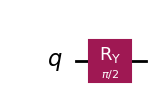

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply an Ry rotation by π/2 (90 degrees) to qubit 0
# Ry(theta) rotates the qubit around the Y-axis by angle theta
# Here theta = π/2, so the state moves 90° on the Bloch sphere
qc.ry(np.pi/2, 0)

# Draw the circuit using Matplotlib style
qc.draw('mpl')

#The Ry(π/2) gate rotates the qubit 90° around the Y-axis.
#Starting from |0⟩ at the north pole, the state moves to the equator and becomes an equal superposition of |0⟩ and |1⟩ without introducing a complex phase.


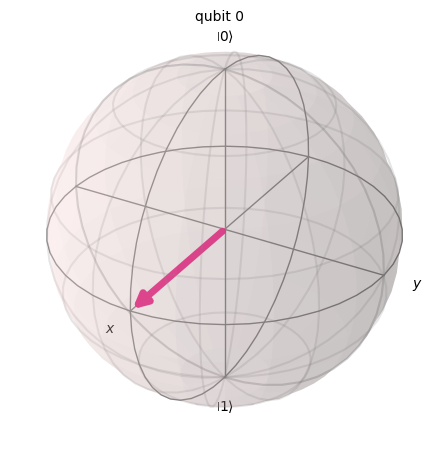

In [ ]:
# Save the statevector so the simulator stores the full quantum state
# Required to retrieve the exact amplitudes after the Ry rotation
qc.save_statevector()

# Execute the circuit on the simulator
# .run(qc) runs the circuit
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum statevector
state = sim.run(qc).result().get_statevector()

# Plot the state on the Bloch sphere
# Visualises how the Ry(π/2) rotation moved the qubit
plot_bloch_multivector(state)

#After applying Ry(π/2), the qubit moves from the north pole to the equator along the Y-axis.
#The Bloch sphere now shows an equal superposition of |0⟩ and |1⟩ with no complex phase — the arrow lies on the X–Z plane.


**Rz Gate**

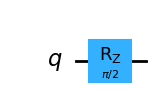

In [ ]:
# Create a quantum circuit with 1 qubit (initial state is |0⟩)
qc = QuantumCircuit(1)

# Apply an Rz rotation by π/2 (90 degrees) to qubit 0
# Rz(theta) rotates the qubit around the Z-axis by angle theta
# Since the qubit is in |0⟩, this only changes phase (no change in probability)
qc.rz(np.pi/2, 0)

# Draw the circuit using Matplotlib style
qc.draw('mpl')

#The Rz(π/2) gate rotates the qubit around the Z-axis, which changes its phase but not its measurement probability.
# Since the qubit starts in |0⟩ (aligned with the Z-axis), the Bloch sphere position does not visibly change.

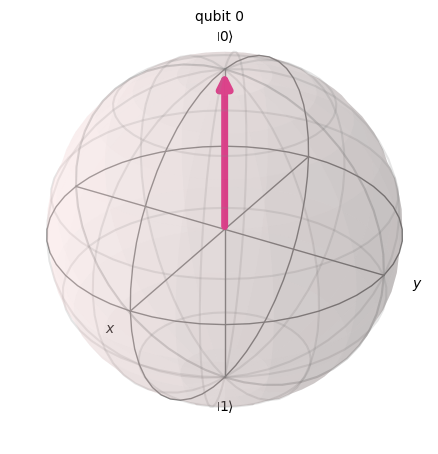

In [ ]:
# Save the statevector so the simulator stores the full quantum state
# Required to retrieve the exact amplitudes after the Rz rotation
qc.save_statevector()

# Execute the circuit on the simulator
# .run(qc) runs the circuit
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum statevector
state = sim.run(qc).result().get_statevector()

# Plot the state on the Bloch sphere
# Visualises the effect of the Rz(π/2) rotation
plot_bloch_multivector(state)

#Even after applying Rz(π/2), the arrow remains at the north pole because the qubit was in |0⟩.
#Rz only changes the phase of the |1⟩ component, and since there was no |1⟩ component, the Bloch sphere does not visibly change.